<a href="https://colab.research.google.com/github/SakshamKumarGahoi/DATASCIENCE/blob/main/DataScience_Class_Assignments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import pandas as pd

In [29]:
students_info = pd.DataFrame({
    "Student_ID": [1, 2, 3, 4, 5],
    "Name": ["Alice", "Bob", "Charlie", "David", "Eva"],
    "Age": [20, 21, 19, 22, 20]
})

In [30]:
students_marks = pd.DataFrame({
    "Student_ID": [3, 4, 5, 6, 7],
    "Course": ["Math", "Science", "English", "Math", "Science"],
    "Marks": [85, 90, 88, 75, 92]
})

In [31]:
inner_merge = pd.merge(students_info, students_marks,
                       on="Student_ID", how="inner")

left_merge = pd.merge(students_info, students_marks,
                      on="Student_ID", how="left")

right_merge = pd.merge(students_info, students_marks,
                       on="Student_ID", how="right")

outer_merge = pd.merge(students_info, students_marks,
                       on="Student_ID", how="outer")


In [32]:
print("Students Info DataFrame:\n", students_info)
print("\nStudents Marks DataFrame:\n", students_marks)

print("\nINNER MERGE:\n", inner_merge)
print("\nLEFT MERGE:\n", left_merge)
print("\nRIGHT MERGE:\n", right_merge)
print("\nOUTER MERGE:\n", outer_merge)

Students Info DataFrame:
    Student_ID     Name  Age
0           1    Alice   20
1           2      Bob   21
2           3  Charlie   19
3           4    David   22
4           5      Eva   20

Students Marks DataFrame:
    Student_ID   Course  Marks
0           3     Math     85
1           4  Science     90
2           5  English     88
3           6     Math     75
4           7  Science     92

INNER MERGE:
    Student_ID     Name  Age   Course  Marks
0           3  Charlie   19     Math     85
1           4    David   22  Science     90
2           5      Eva   20  English     88

LEFT MERGE:
    Student_ID     Name  Age   Course  Marks
0           1    Alice   20      NaN    NaN
1           2      Bob   21      NaN    NaN
2           3  Charlie   19     Math   85.0
3           4    David   22  Science   90.0
4           5      Eva   20  English   88.0

RIGHT MERGE:
    Student_ID     Name   Age   Course  Marks
0           3  Charlie  19.0     Math     85
1           4    David  

In [33]:
employees = pd.DataFrame({
    "Emp_ID": [101, 102, 103, 104, 105],
    "Name": ["John", "Emma", "Michael", "Sophia", "Daniel"],
    "Department": ["HR", "IT", "IT", "Finance", "HR"],
    "Salary": [40000, 60000, 55000, 65000, 45000],
    "Experience_Years": [2, 5, 4, 6, 3]
})

In [34]:
print(employees)

   Emp_ID     Name Department  Salary  Experience_Years
0     101     John         HR   40000                 2
1     102     Emma         IT   60000                 5
2     103  Michael         IT   55000                 4
3     104   Sophia    Finance   65000                 6
4     105   Daniel         HR   45000                 3


In [35]:

it_employees = employees[employees["Department"] == "IT"]
print("\nEmployees in IT Department:")
print(it_employees)

average_salary = employees["Salary"].mean()
print("\nAverage Salary:", average_salary)

highest_salary = employees.loc[employees["Salary"].idxmax()]
print("\nEmployee with Highest Salary:")
print(highest_salary)

employees["Updated_Salary"] = employees["Salary"] * 1.10
print("\nAfter 10% Salary Increase:")
print(employees)

dept_avg_salary = employees.groupby("Department")["Salary"].mean()
print("\nAverage Salary by Department:")
print(dept_avg_salary)


Employees in IT Department:
   Emp_ID     Name Department  Salary  Experience_Years
1     102     Emma         IT   60000                 5
2     103  Michael         IT   55000                 4

Average Salary: 53000.0

Employee with Highest Salary:
Emp_ID                  104
Name                 Sophia
Department          Finance
Salary                65000
Experience_Years          6
Name: 3, dtype: object

After 10% Salary Increase:
   Emp_ID     Name Department  Salary  Experience_Years  Updated_Salary
0     101     John         HR   40000                 2         44000.0
1     102     Emma         IT   60000                 5         66000.0
2     103  Michael         IT   55000                 4         60500.0
3     104   Sophia    Finance   65000                 6         71500.0
4     105   Daniel         HR   45000                 3         49500.0

Average Salary by Department:
Department
Finance    65000.0
HR         42500.0
IT         57500.0
Name: Salary, dtype: floa

In [36]:
sales_data = pd.DataFrame({
    "Salesperson": ["Alice", "Bob", "Charlie"],
    "Jan": [5000, 7000, 6000],
    "Feb": [5500, 6500, 6200],
    "Mar": [6000, 7200, 6800]
})

In [37]:
print(sales_data)


  Salesperson   Jan   Feb   Mar
0       Alice  5000  5500  6000
1         Bob  7000  6500  7200
2     Charlie  6000  6200  6800


In [38]:
melted_sales = pd.melt(
    sales_data,
    id_vars=["Salesperson"],
    var_name="Month",
    value_name="Sales"
)

print(melted_sales)

pivot_sales = melted_sales.pivot(
    index="Salesperson",
    columns="Month",
    values="Sales"
)

print(pivot_sales)

total_sales = melted_sales.groupby("Salesperson")["Sales"].sum()
print("\nTotal Sales per Salesperson:")
print(total_sales)

average_sales = melted_sales["Sales"].mean()
print("\nAverage Monthly Sales:", average_sales)

max_sales = melted_sales["Sales"].max()
print("\nMaximum Sales Value:", max_sales)

  Salesperson Month  Sales
0       Alice   Jan   5000
1         Bob   Jan   7000
2     Charlie   Jan   6000
3       Alice   Feb   5500
4         Bob   Feb   6500
5     Charlie   Feb   6200
6       Alice   Mar   6000
7         Bob   Mar   7200
8     Charlie   Mar   6800
Month         Feb   Jan   Mar
Salesperson                  
Alice        5500  5000  6000
Bob          6500  7000  7200
Charlie      6200  6000  6800

Total Sales per Salesperson:
Salesperson
Alice      16500
Bob        20700
Charlie    19000
Name: Sales, dtype: int64

Average Monthly Sales: 6244.444444444444

Maximum Sales Value: 7200


In [39]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/sample_data/House Price - House Price.csv')

print("Shape of dataset:", df.shape)

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("\nColumns with missing values:")
print(missing)

Shape of dataset: (1460, 81)

Columns with missing values:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [40]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
missing_percent = df.isnull().sum() / len(df)

cols_to_drop = missing_percent[missing_percent > 0.5].index

df_drop_cols = df.drop(columns=cols_to_drop)

print("Dropped columns:", list(cols_to_drop))
print("New shape:", df_drop_cols.shape)

Dropped columns: ['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature']
New shape: (1460, 76)


In [42]:
df_drop_rows = df.dropna()

print("Shape after dropping rows:", df_drop_rows.shape)

print(df_drop_rows.head())

Shape after dropping rows: (0, 81)
Empty DataFrame
Columns: [Id, MSSubClass, MSZoning, LotFrontage, LotArea, Street, Alley, LotShape, LandContour, Utilities, LotConfig, LandSlope, Neighborhood, Condition1, Condition2, BldgType, HouseStyle, OverallQual, OverallCond, YearBuilt, YearRemodAdd, RoofStyle, RoofMatl, Exterior1st, Exterior2nd, MasVnrType, MasVnrArea, ExterQual, ExterCond, Foundation, BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinSF1, BsmtFinType2, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF, Heating, HeatingQC, CentralAir, Electrical, 1stFlrSF, 2ndFlrSF, LowQualFinSF, GrLivArea, BsmtFullBath, BsmtHalfBath, FullBath, HalfBath, BedroomAbvGr, KitchenAbvGr, KitchenQual, TotRmsAbvGrd, Functional, Fireplaces, FireplaceQu, GarageType, GarageYrBlt, GarageFinish, GarageCars, GarageArea, GarageQual, GarageCond, PavedDrive, WoodDeckSF, OpenPorchSF, EnclosedPorch, 3SsnPorch, ScreenPorch, PoolArea, PoolQC, Fence, MiscFeature, MiscVal, MoSold, YrSold, SaleType, SaleCondition, SalePrice]
Ind

In [43]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [44]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='median')

df[num_cols] = num_imputer.fit_transform(df[num_cols])

In [45]:
cat_imputer = SimpleImputer(strategy='most_frequent')

df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [46]:
print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


In [47]:
from sklearn.impute import KNNImputer

num_df = df.select_dtypes(include=['int64','float64'])

knn_imputer = KNNImputer(n_neighbors=5)

num_df_imputed = pd.DataFrame(
    knn_imputer.fit_transform(num_df),
    columns=num_df.columns
)

print(num_df_imputed.shape)
print(num_df_imputed.head())

(1460, 38)
    Id  MSSubClass  LotFrontage  LotArea  OverallQual  OverallCond  YearBuilt  \
0  1.0        60.0         65.0   8450.0          7.0          5.0     2003.0   
1  2.0        20.0         80.0   9600.0          6.0          8.0     1976.0   
2  3.0        60.0         68.0  11250.0          7.0          5.0     2001.0   
3  4.0        70.0         60.0   9550.0          7.0          5.0     1915.0   
4  5.0        60.0         84.0  14260.0          8.0          5.0     2000.0   

   YearRemodAdd  MasVnrArea  BsmtFinSF1  ...  WoodDeckSF  OpenPorchSF  \
0        2003.0       196.0       706.0  ...         0.0         61.0   
1        1976.0         0.0       978.0  ...       298.0          0.0   
2        2002.0       162.0       486.0  ...         0.0         42.0   
3        1970.0         0.0       216.0  ...         0.0         35.0   
4        2000.0       350.0       655.0  ...       192.0         84.0   

   EnclosedPorch  3SsnPorch  ScreenPorch  PoolArea  MiscVal  Mo

In [48]:
print("Final missing values:", df.isnull().sum().sum())

df.to_csv('/content/clean_house_price_data.csv', index=False)

Final missing values: 0


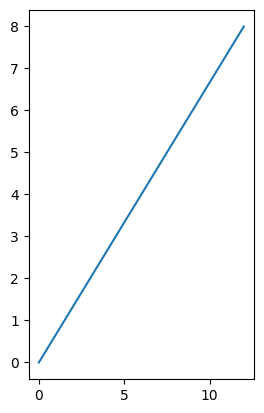

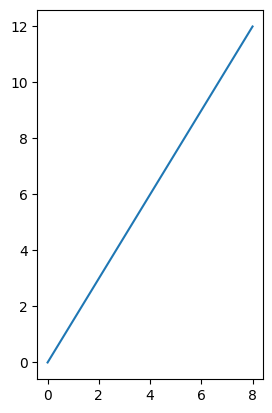

In [49]:
import numpy as np
import matplotlib.pyplot as pl
import pandas as pd
x = np.arange(0, 15, 3)
y = np.arange(0, 10, 2)
pl.subplot(1,2,2)
pl.plot(x,y)
pl.show()

x = np.arange(0, 10, 2)
y = np.arange(0, 15, 3)
pl.subplot(1,2,2)
pl.plot(x,y)
pl.show()

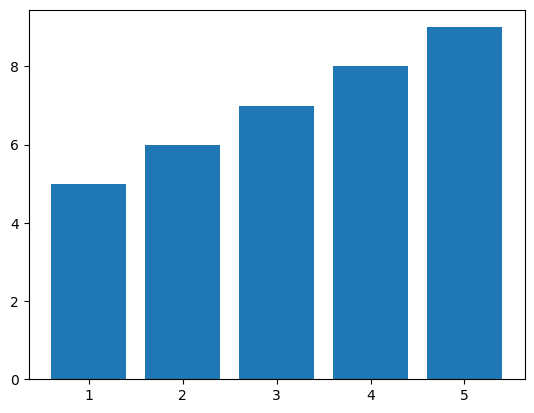

In [50]:
import numpy as np
import matplotlib.pyplot as pl

x = np.array([1,2,3,4,5])
y = np.array([5,6,7,8,9])

pl.bar(x,y)
pl.show()

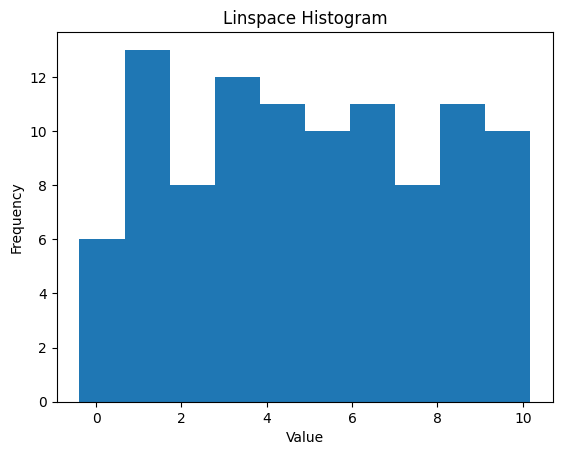

In [55]:
import numpy as np
import matplotlib.pyplot as plt

data = np.linspace(0, 10, 100) + np.random.randn(100) * 0.5

plt.hist(data, bins=10)
plt.title("Linspace Histogram")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()